<a href="https://colab.research.google.com/github/nansu2026/Dissertation/blob/main/Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Download the EirGrid dataset directly from GitHub
import urllib.request, zipfile, os

url = "https://github.com/Daniel-Parke/EirGrid_Data_Download/archive/refs/heads/main.zip"
zip_filename = "EirGrid_Data_Download-main.zip"
extract_to = "/content/extracted"

if not os.path.exists(zip_filename):
    print("Downloading dataset from GitHub...")
    urllib.request.urlretrieve(url, zip_filename)
    print("Download complete.")

if not os.path.exists(extract_to):
    with zipfile.ZipFile(zip_filename, 'r') as z:
        z.extractall(extract_to)
    print("Extracted.")
else:
    print("Already extracted, skipping.")

roi_path = os.path.join(extract_to, "EirGrid_Data_Download-main", "Downloaded_Data", "ROI")
print(os.listdir(roi_path)[:5])

Download complete.
Extracted.
['ROI_demandactual_18_Eirgrid.csv', 'ROI_generationactual_23_Eirgrid.csv', 'ROI_generationactual_14_Eirgrid.csv', 'ROI_demandactual_19_Eirgrid.csv', 'ROI_co2emission_17_Eirgrid.csv']


In [ ]:
# Preview the raw file structure — no header row, 4 columns: DateTime, Type, Region, Value
import pandas as pd
import os

raw = pd.read_csv(os.path.join(roi_path, "ROI_demandactual_14_Eirgrid.csv"), header=None, nrows=15)
print(raw.to_string())

                       0              1    2       3
0   01-Jan-2014 00:00:00  SYSTEM_DEMAND  ROI  2899.0
1   01-Jan-2014 00:15:00  SYSTEM_DEMAND  ROI  2869.0
2   01-Jan-2014 00:30:00  SYSTEM_DEMAND  ROI  2826.0
3   01-Jan-2014 00:45:00  SYSTEM_DEMAND  ROI  2787.0
4   01-Jan-2014 01:00:00  SYSTEM_DEMAND  ROI  2724.0
5   01-Jan-2014 01:15:00  SYSTEM_DEMAND  ROI  2686.0
6   01-Jan-2014 01:30:00  SYSTEM_DEMAND  ROI  2597.0
7   01-Jan-2014 01:45:00  SYSTEM_DEMAND  ROI  2543.0
8   01-Jan-2014 02:00:00  SYSTEM_DEMAND  ROI  2483.0
9   01-Jan-2014 02:15:00  SYSTEM_DEMAND  ROI  2437.0
10  01-Jan-2014 02:30:00  SYSTEM_DEMAND  ROI  2392.0
11  01-Jan-2014 02:45:00  SYSTEM_DEMAND  ROI  2341.0
12  01-Jan-2014 03:00:00  SYSTEM_DEMAND  ROI  2303.0
13  01-Jan-2014 03:15:00  SYSTEM_DEMAND  ROI  2273.0
14  01-Jan-2014 03:30:00  SYSTEM_DEMAND  ROI  2227.0


In [ ]:
# Merge all 11 yearly ROI demand files into a 15-minute resolution dataset with calendar features
import pandas as pd
import glob
import os

all_dfs = []
for f in sorted(glob.glob(os.path.join(roi_path, "ROI_demandactual_*.csv"))):
    temp = pd.read_csv(f, header=None, names=['DateTime', 'Type', 'Region', 'SYSTEM_DEMAND_MW'])
    all_dfs.append(temp)

df = pd.concat(all_dfs, ignore_index=True)
df['DateTime'] = pd.to_datetime(df['DateTime'], dayfirst=True)
df['SYSTEM_DEMAND_MW'] = pd.to_numeric(df['SYSTEM_DEMAND_MW'], errors='coerce')
df = df.sort_values('DateTime').reset_index(drop=True)

# Add time features
df['Year']      = df['DateTime'].dt.year
df['Month']     = df['DateTime'].dt.month
df['Day']       = df['DateTime'].dt.day
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['Hour']      = df['DateTime'].dt.hour
df['Minute']    = df['DateTime'].dt.minute
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Fill missing
df['SYSTEM_DEMAND_MW'] = df['SYSTEM_DEMAND_MW'].interpolate(method='linear')

print(f"Total rows: {len(df):,}")
print(df.head(10).to_string())
print(df.describe())

# Download
df.to_csv("EirGrid_Ireland_15min_2014_2025.csv", index=False)
#from google.colab import files
#files.download("EirGrid_Ireland_15min_2014_2025.csv")

Total rows: 397,344
             DateTime           Type Region  SYSTEM_DEMAND_MW  Year  Month  Day  DayOfWeek  Hour  Minute  IsWeekend
0 2014-01-01 00:00:00  SYSTEM_DEMAND    ROI            2899.0  2014      1    1          2     0       0          0
1 2014-01-01 00:15:00  SYSTEM_DEMAND    ROI            2869.0  2014      1    1          2     0      15          0
2 2014-01-01 00:30:00  SYSTEM_DEMAND    ROI            2826.0  2014      1    1          2     0      30          0
3 2014-01-01 00:45:00  SYSTEM_DEMAND    ROI            2787.0  2014      1    1          2     0      45          0
4 2014-01-01 01:00:00  SYSTEM_DEMAND    ROI            2724.0  2014      1    1          2     1       0          0
5 2014-01-01 01:15:00  SYSTEM_DEMAND    ROI            2686.0  2014      1    1          2     1      15          0
6 2014-01-01 01:30:00  SYSTEM_DEMAND    ROI            2597.0  2014      1    1          2     1      30          0
7 2014-01-01 01:45:00  SYSTEM_DEMAND    ROI         

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Resample the merged data into hourly averages and run data-quality checks
import pandas as pd
import glob
import os

# ── Combine all files ───────────────────────────────────────
all_dfs = []
for f in sorted(glob.glob(os.path.join(roi_path, "ROI_demandactual_*.csv"))):
    temp = pd.read_csv(f, header=None, names=['DateTime', 'Type', 'Region', 'SYSTEM_DEMAND_MW'])
    all_dfs.append(temp)

df = pd.concat(all_dfs, ignore_index=True)

# ── Clean & convert ─────────────────────────────────────────
df['DateTime'] = pd.to_datetime(df['DateTime'], dayfirst=True)
df['SYSTEM_DEMAND_MW'] = pd.to_numeric(df['SYSTEM_DEMAND_MW'], errors='coerce')
df = df.sort_values('DateTime').reset_index(drop=True)

# ── Resample to hourly ──────────────────────────────────────
df_hourly = df.set_index('DateTime').resample('H')['SYSTEM_DEMAND_MW'].mean().reset_index()

# ── Add time features ───────────────────────────────────────
df_hourly['Year']      = df_hourly['DateTime'].dt.year
df_hourly['Month']     = df_hourly['DateTime'].dt.month
df_hourly['Day']       = df_hourly['DateTime'].dt.day
df_hourly['DayOfWeek'] = df_hourly['DateTime'].dt.dayofweek  # 0=Mon, 6=Sun
df_hourly['Hour']      = df_hourly['DateTime'].dt.hour
df_hourly['IsWeekend'] = df_hourly['DayOfWeek'].isin([5, 6]).astype(int)

# ── Handle missing values ───────────────────────────────────
df_hourly['SYSTEM_DEMAND_MW'] = df_hourly['SYSTEM_DEMAND_MW'].interpolate(method='linear')

# ── Preview ─────────────────────────────────────────────────
print("=== COLUMN NAMES (ATTRIBUTES) ===")
print(df_hourly.columns.tolist())

print(f"\n=== DATASET SHAPE ===")
print(f"Rows: {len(df_hourly):,}  |  Columns: {df_hourly.shape[1]}")

print(f"\n=== DATE RANGE ===")
print(f"{df_hourly['DateTime'].min()} → {df_hourly['DateTime'].max()}")

print(f"\n=== FIRST 10 ROWS ===")
print(df_hourly.head(10).to_string())

print(f"\n=== STATS FOR ALL COLUMNS ===")
print(df_hourly.describe())

# ===============================
# Data Quality Checks
# ===============================

print("="*50)
print("DATA QUALITY CHECK")
print("="*50)

print("\nMissing Values:")
print(df_hourly.isnull().sum())

print("\nDuplicate Rows:")
print(df_hourly.duplicated().sum())

print("\nDuplicate DateTime Values:")
print(df_hourly['DateTime'].duplicated().sum())

print("\nData Types:")
print(df_hourly.dtypes)

print("\nSummary Statistics:")
print(df_hourly.describe())

# ── Download as CSV ─────────────────────────────────────────
df_hourly.to_csv("EirGrid_Ireland_Demand_2014_2025_Hourly.csv", index=False)
print("\n✅ File saved! Now downloading...")

#from google.colab import files
#files.download("EirGrid_Ireland_Demand_2014_2025_Hourly.csv")

/tmp/ipykernel_1082/3245141682.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.set_index('DateTime').resample('H')['SYSTEM_DEMAND_MW'].mean().reset_index()


=== COLUMN NAMES (ATTRIBUTES) ===
['DateTime', 'SYSTEM_DEMAND_MW', 'Year', 'Month', 'Day', 'DayOfWeek', 'Hour', 'IsWeekend']

=== DATASET SHAPE ===
Rows: 96,454  |  Columns: 8

=== DATE RANGE ===
2014-01-01 00:00:00 → 2025-01-01 21:00:00

=== FIRST 10 ROWS ===
             DateTime  SYSTEM_DEMAND_MW  Year  Month  Day  DayOfWeek  Hour  IsWeekend
0 2014-01-01 00:00:00           2845.25  2014      1    1          2     0          0
1 2014-01-01 01:00:00           2637.50  2014      1    1          2     1          0
2 2014-01-01 02:00:00           2413.25  2014      1    1          2     2          0
3 2014-01-01 03:00:00           2251.50  2014      1    1          2     3          0
4 2014-01-01 04:00:00           2132.25  2014      1    1          2     4          0
5 2014-01-01 05:00:00           2078.25  2014      1    1          2     5          0
6 2014-01-01 06:00:00           2088.50  2014      1    1          2     6          0
7 2014-01-01 07:00:00           2122.00  2014      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Standardize the working variable name to 'df' for all following cells
df = df_hourly.copy()
print(f"Rows: {len(df):,}   |   Columns: {df.shape[1]}")
df.head()

Rows: 96,454   |   Columns: 8


,DateTime,SYSTEM_DEMAND_MW,Year,Month,Day,DayOfWeek,Hour,IsWeekend
0,2014-01-01 00:00:00,2845.25,2014,1,1,2,0,0
1,2014-01-01 01:00:00,2637.50,2014,1,1,2,1,0
2,2014-01-01 02:00:00,2413.25,2014,1,1,2,2,0
3,2014-01-01 03:00:00,2251.50,2014,1,1,2,3,0
4,2014-01-01 04:00:00,2132.25,2014,1,1,2,4,0


In [ ]:
# Import libraries used for modeling, evaluation, and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Print summary statistics for the demand column
print(df['SYSTEM_DEMAND_MW'].describe())

count    96454.000000
mean      3393.187960
std        681.830168
min       1684.250000
25%       2866.250000
50%       3423.250000
75%       3917.000000
max       5517.750000
Name: SYSTEM_DEMAND_MW, dtype: float64


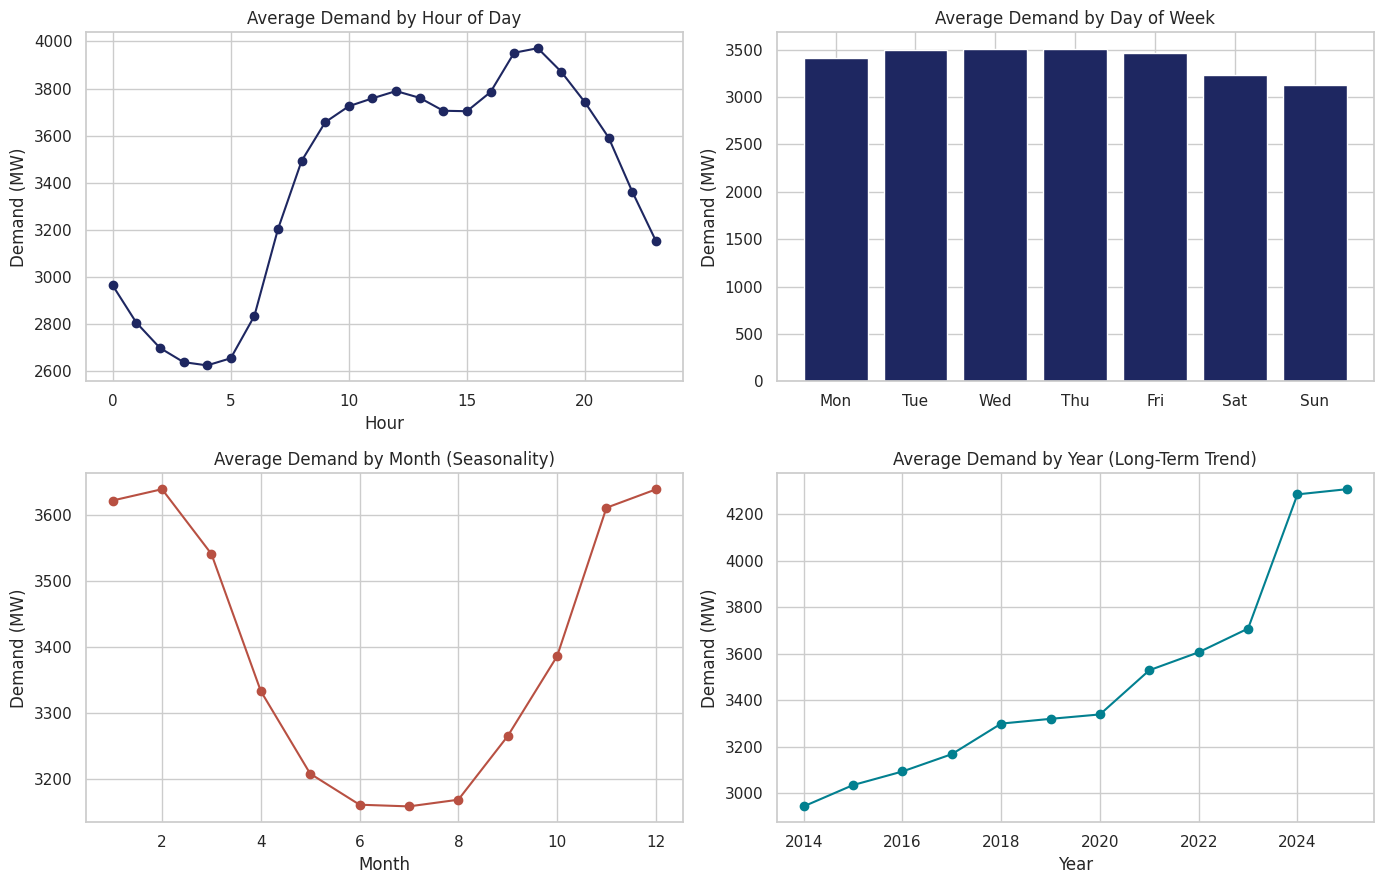

In [ ]:
# Plot average demand by hour, day of week, month, and year
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

hourly_avg = df.groupby('Hour')['SYSTEM_DEMAND_MW'].mean()
axes[0,0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='#1E2761')
axes[0,0].set_title('Average Demand by Hour of Day')
axes[0,0].set_xlabel('Hour'); axes[0,0].set_ylabel('Demand (MW)')

dow_avg = df.groupby('DayOfWeek')['SYSTEM_DEMAND_MW'].mean()
axes[0,1].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow_avg.values, color='#1E2761')
axes[0,1].set_title('Average Demand by Day of Week')
axes[0,1].set_ylabel('Demand (MW)')

month_avg = df.groupby('Month')['SYSTEM_DEMAND_MW'].mean()
axes[1,0].plot(month_avg.index, month_avg.values, marker='o', color='#B85042')
axes[1,0].set_title('Average Demand by Month (Seasonality)')
axes[1,0].set_xlabel('Month'); axes[1,0].set_ylabel('Demand (MW)')

year_avg = df.groupby('Year')['SYSTEM_DEMAND_MW'].mean()
axes[1,1].plot(year_avg.index, year_avg.values, marker='o', color='#028090')
axes[1,1].set_title('Average Demand by Year (Long-Term Trend)')
axes[1,1].set_xlabel('Year'); axes[1,1].set_ylabel('Demand (MW)')

plt.tight_layout()
plt.show()

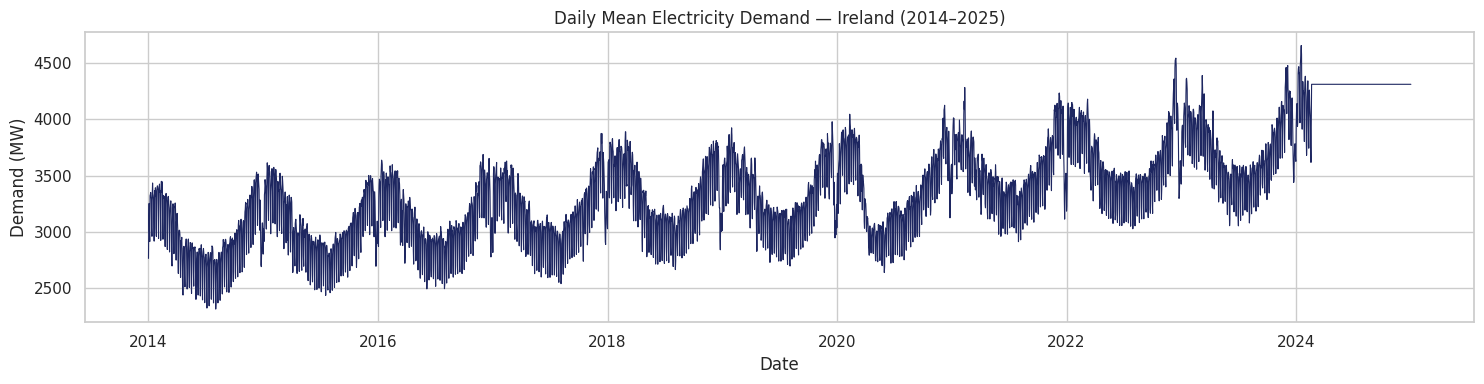

In [ ]:
# Plot the full daily mean demand time series, 2014–2025
daily = df.set_index('DateTime')['SYSTEM_DEMAND_MW'].resample('D').mean()

plt.figure(figsize=(15, 4))
plt.plot(daily.index, daily.values, color='#1E2761', linewidth=0.8)
plt.title('Daily Mean Electricity Demand — Ireland (2014–2025)')
plt.xlabel('Date'); plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

In [ ]:
# Split data chronologically at 2023-01-01 and define the shared evaluation function
SPLIT_DATE = "2023-01-01"

train_df = df[df['DateTime'] < SPLIT_DATE].reset_index(drop=True)
test_df  = df[df['DateTime'] >= SPLIT_DATE].reset_index(drop=True)

print(f"Train: {len(train_df):,} rows  ({train_df['DateTime'].min()} -> {train_df['DateTime'].max()})")
print(f"Test:  {len(test_df):,} rows  ({test_df['DateTime'].min()} -> {test_df['DateTime'].max()})")

def evaluate_forecast(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100
    print(f"{model_name:15s} | MAE: {mae:8.2f} MW | RMSE: {rmse:8.2f} MW | MAPE: {mape:6.2f}%")
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []

Train: 78,888 rows  (2014-01-01 00:00:00 -> 2022-12-31 23:00:00)
Test:  17,566 rows  (2023-01-01 00:00:00 -> 2025-01-01 21:00:00)


In [ ]:
# Install pmdarima for automatic ARIMA order selection
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.8 MB/s eta 0:00:00


In [ ]:
# Run the Augmented Dickey-Fuller test to check stationarity
from statsmodels.tsa.stattools import adfuller

series_full = train_df.set_index('DateTime')['SYSTEM_DEMAND_MW']

adf_result = adfuller(series_full)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("=> Series is stationary (reject H0).")
else:
    print("=> Series is NOT stationary — differencing will be applied by auto_arima (d>0).")

ADF Statistic: -12.5842
p-value:       0.0000
=> Series is stationary (reject H0).


In [ ]:
# Use auto_arima to search for the best (p,d,q) order
import pmdarima as pm

ARIMA_WINDOW_HOURS = 24 * 365 * 2
arima_train_series = series_full.iloc[-ARIMA_WINDOW_HOURS:]

print(f"Selecting ARIMA order on {len(arima_train_series):,} recent training hours...")

auto_model = pm.auto_arima(
    arima_train_series,
    start_p=0, start_q=0, max_p=5, max_q=5,
    d=None,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())
order = auto_model.order
print(f"\nSelected order (p,d,q): {order}")

Selecting ARIMA order on 17,520 recent training hours...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=232349.536, Time=1.30 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=215968.884, Time=0.72 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=218261.521, Time=8.49 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=232347.536, Time=0.41 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=212306.491, Time=4.27 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=211971.375, Time=3.45 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=211698.952, Time=3.98 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=211348.887, Time=4.07 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=46.85 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=40.24 sec
 ARIMA(5,1,0)(0,0,0)[0]             : AIC=211346.887, Time=1.14 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=211696.951, Time=0.92 sec
 ARIMA(5,1,1)(0,0,0)[0]             : AIC=inf, Time=18.12 sec
 ARIMA(4,1,1)(0,0,0)[0]           

In [ ]:
# Fit the final ARIMA model and forecast the test period blind (multi-step, no peeking)
from statsmodels.tsa.arima.model import ARIMA

print("Fitting final ARIMA model — this may take a few minutes...")
arima_final = ARIMA(arima_train_series, order=order)
arima_fit = arima_final.fit()

n_forecast = len(test_df)
arima_forecast = arima_fit.forecast(steps=n_forecast)

test_df['ARIMA_Pred'] = arima_forecast.values
results.append(evaluate_forecast(test_df['SYSTEM_DEMAND_MW'], test_df['ARIMA_Pred'], "ARIMA"))

Fitting final ARIMA model — this may take a few minutes...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


ARIMA           | MAE:   538.70 MW | RMSE:   594.17 MW | MAPE:  13.72%


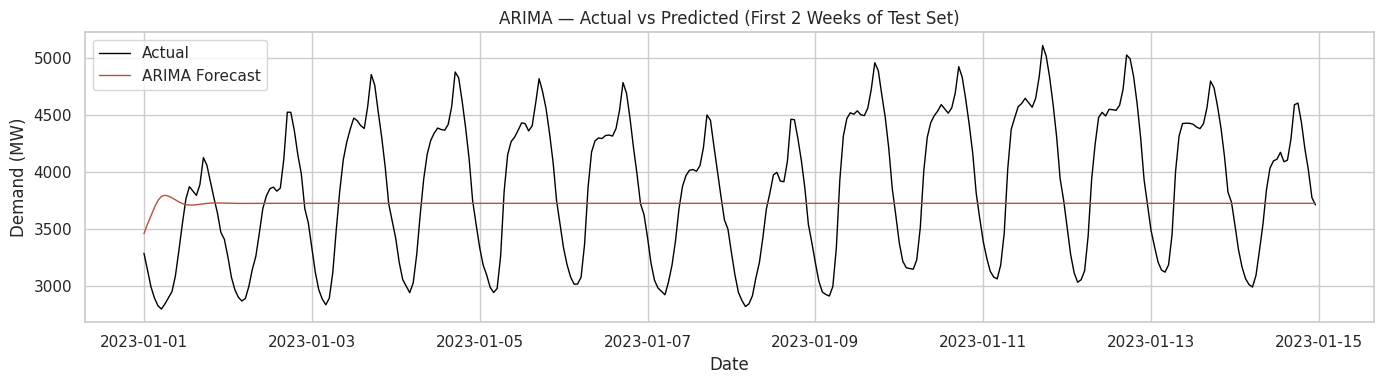

In [ ]:
# Plot ARIMA's forecast against actual demand for the first two weeks of the test set
plot_slice = test_df.iloc[:24*14]

plt.figure(figsize=(14, 4))
plt.plot(plot_slice['DateTime'], plot_slice['SYSTEM_DEMAND_MW'], label='Actual', color='black', linewidth=1)
plt.plot(plot_slice['DateTime'], plot_slice['ARIMA_Pred'], label='ARIMA Forecast', color='#B85042', linewidth=1)
plt.title('ARIMA — Actual vs Predicted (First 2 Weeks of Test Set)')
plt.xlabel('Date'); plt.ylabel('Demand (MW)'); plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Build lag features (1h, 24h, 168h) since Random Forest has no built-in sense of time
def add_lag_features(data):
    data = data.copy()
    data['Lag_1h']   = data['SYSTEM_DEMAND_MW'].shift(1)
    data['Lag_24h']  = data['SYSTEM_DEMAND_MW'].shift(24)
    data['Lag_168h'] = data['SYSTEM_DEMAND_MW'].shift(168)  # same hour, previous week
    return data

df_lagged = add_lag_features(df)
df_lagged = df_lagged.dropna().reset_index(drop=True)

train_lagged = df_lagged[df_lagged['DateTime'] < SPLIT_DATE].reset_index(drop=True)
test_lagged  = df_lagged[df_lagged['DateTime'] >= SPLIT_DATE].reset_index(drop=True)

CALENDAR_FEATURES = ['Hour', 'DayOfWeek', 'IsWeekend', 'Month', 'Day', 'Year']
LAG_FEATURES      = ['Lag_1h', 'Lag_24h', 'Lag_168h']
TARGET            = 'SYSTEM_DEMAND_MW'

print(f"Train rows: {len(train_lagged):,}  |  Test rows: {len(test_lagged):,}")

Train rows: 78,720  |  Test rows: 17,566


In [ ]:
# Train a baseline Random Forest using calendar features only
from sklearn.ensemble import RandomForestRegressor

X_train_cal = train_lagged[CALENDAR_FEATURES]
y_train_cal = train_lagged[TARGET]
X_test_cal  = test_lagged[CALENDAR_FEATURES]
y_test_cal  = test_lagged[TARGET]

rf_baseline = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_cal, y_train_cal)
rf_baseline_pred = rf_baseline.predict(X_test_cal)

results.append(evaluate_forecast(y_test_cal, rf_baseline_pred, "RF (Calendar)"))

RF (Calendar)   | MAE:   434.60 MW | RMSE:   641.45 MW | MAPE:  10.40%


In [ ]:
# Train Random Forest with calendar + lag features and compare against the baseline
FEATURES = CALENDAR_FEATURES + LAG_FEATURES

X_train = train_lagged[FEATURES]
y_train = train_lagged[TARGET]
X_test  = test_lagged[FEATURES]
y_test  = test_lagged[TARGET]

rf_full = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_full.fit(X_train, y_train)
rf_full_pred = rf_full.predict(X_test)

results.append(evaluate_forecast(y_test, rf_full_pred, "RF (Cal+Lag)"))
test_lagged['RF_Pred'] = rf_full_pred

print("\nComparison: adding lag features to Random Forest")
print(f"  Calendar only : MAE {mean_absolute_error(y_test_cal, rf_baseline_pred):.2f} MW")
print(f"  Calendar+Lag  : MAE {mean_absolute_error(y_test, rf_full_pred):.2f} MW")

RF (Cal+Lag)    | MAE:    78.31 MW | RMSE:   108.09 MW | MAPE:   1.90%

Comparison: adding lag features to Random Forest
  Calendar only : MAE 434.60 MW
  Calendar+Lag  : MAE 78.31 MW


In [ ]:
# Generate ARIMA walk-forward, one-step-ahead predictions using the true previous value each step
# Build one continuous series across train + test
full_series = df.set_index('DateTime')['SYSTEM_DEMAND_MW']

n_train = len(train_df)
n_total = len(full_series)

# Re-apply the already-fitted ARIMA(5,1,0) parameters to the full series (no re-estimation, refit=False)
arima_walkforward = arima_fit.apply(full_series, refit=False)

# One-step-ahead predictions across the whole test period:
# dynamic=False means at every hour, the model uses the TRUE previous value, not its own earlier guess
pred = arima_walkforward.get_prediction(start=n_train, end=n_total - 1, dynamic=False)
arima_pred_wf = pred.predicted_mean.values

test_df['ARIMA_Pred_WF'] = arima_pred_wf

# Keep the original blind forecast result for discussion, but label it clearly
results[0]['Model'] = "ARIMA (Blind Multi-Step)"

results.append(evaluate_forecast(test_df['SYSTEM_DEMAND_MW'], test_df['ARIMA_Pred_WF'], "ARIMA (Walk-Forward)"))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


ARIMA (Walk-Forward) | MAE:    39.80 MW | RMSE:    73.01 MW | MAPE:   1.05%


In [ ]:
# Scale demand values and build 24-hour sliding-window sequences for the LSTM
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

WINDOW = 24  # past 24 hours used to predict the next hour

# Fit scaler on TRAIN ONLY to avoid leaking test-set information
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[['SYSTEM_DEMAND_MW']])
test_scaled  = scaler.transform(test_df[['SYSTEM_DEMAND_MW']])

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

combined_scaled = np.concatenate([train_scaled[-WINDOW:], test_scaled])

X_train_lstm, y_train_lstm = create_sequences(train_scaled, WINDOW)
X_test_lstm,  y_test_lstm  = create_sequences(combined_scaled, WINDOW)

X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm  = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

print(f"X_train_lstm: {X_train_lstm.shape}  |  X_test_lstm: {X_test_lstm.shape}")

X_train_lstm: (78864, 24, 1)  |  X_test_lstm: (17566, 24, 1)


In [ ]:
# Define the LSTM model: one LSTM(64) layer feeding into a single output neuron
lstm_model = Sequential([
    Input(shape=(WINDOW, 1)),
    LSTM(64, activation='tanh'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Check GPU availability and train the LSTM with early stopping
import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0106 - val_loss: 0.0020
Epoch 2/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0017 - val_loss: 0.0026
Epoch 3/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0011 - val_loss: 7.8829e-04
Epoch 4/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.7959e-04 - val_loss: 6.7870e-04
Epoch 5/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.7651e-04 - val_loss: 6.1451e-04
Epoch 6/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.0725e-04 - val_loss: 5.4265e-04
Epoch 7/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6400e-04 - val_loss: 4.8678e-04
Epoch 8/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.0861e-04 - val_loss: 4.5306e-04
Epoch 9/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.6177e-04 - val_loss: 6.4673e-04
Epoch 10/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 5.3001e-04 - val_loss: 4.2495e

In [ ]:
# Generate LSTM predictions, inverse-transform to MW, and score against actual demand
lstm_pred_scaled = lstm_model.predict(X_test_lstm)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()

lstm_actual = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

results.append(evaluate_forecast(lstm_actual, lstm_pred, "LSTM"))

test_df_lstm = test_df.iloc[:len(lstm_pred)].copy()
test_df_lstm['LSTM_Pred'] = lstm_pred

549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM            | MAE:    87.06 MW | RMSE:   104.88 MW | MAPE:   2.10%


In [ ]:
# Combine all model results into a final leaderboard, sorted by RMSE, with accuracy %
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE').reset_index(drop=True)
print(results_df.to_string(index=False))
results_df['Accuracy (%)'] = 100 - results_df['MAPE']
results_df

                   Model        MAE       RMSE      MAPE
    ARIMA (Walk-Forward)  39.798638  73.012434  1.048519
                    LSTM  87.057401 104.882982  2.099210
            RF (Cal+Lag)  78.306888 108.092805  1.895918
ARIMA (Blind Multi-Step) 538.699158 594.170261 13.716860
           RF (Calendar) 434.602559 641.449843 10.396229


,Model,MAE,RMSE,MAPE,Accuracy (%)
0,ARIMA (Walk-Forward),39.798638,73.012434,1.048519,98.951481
1,LSTM,87.057401,104.882982,2.099210,97.900790
2,RF (Cal+Lag),78.306888,108.092805,1.895918,98.104082
3,ARIMA (Blind Multi-Step),538.699158,594.170261,13.716860,86.283140
4,RF (Calendar),434.602559,641.449843,10.396229,89.603771
